In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
df=pd.read_csv('/kaggle/input/datasets/nabinpaaudel/data-science/data_science_job.csv')
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [3]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [4]:
df.shape

(19158, 13)

In [5]:
cols=[var for var in df.columns if df[var].isnull().mean()<0.05 and df[var].isnull().mean()>0]
cols


['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [6]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
3062,0.802,Full time course,High School,5.0,2.0
4498,0.910,no_enrollment,Graduate,5.0,66.0
13856,0.920,Part time course,Graduate,4.0,13.0
11300,0.624,Full time course,Graduate,7.0,26.0
3874,0.804,no_enrollment,Graduate,3.0,13.0


In [7]:
  len(df[cols].dropna())/len(df)

0.8968577095730244

In [8]:
new_df=df[cols].dropna()

In [9]:
new_df.shape,df.shape

((17182, 5), (19158, 13))

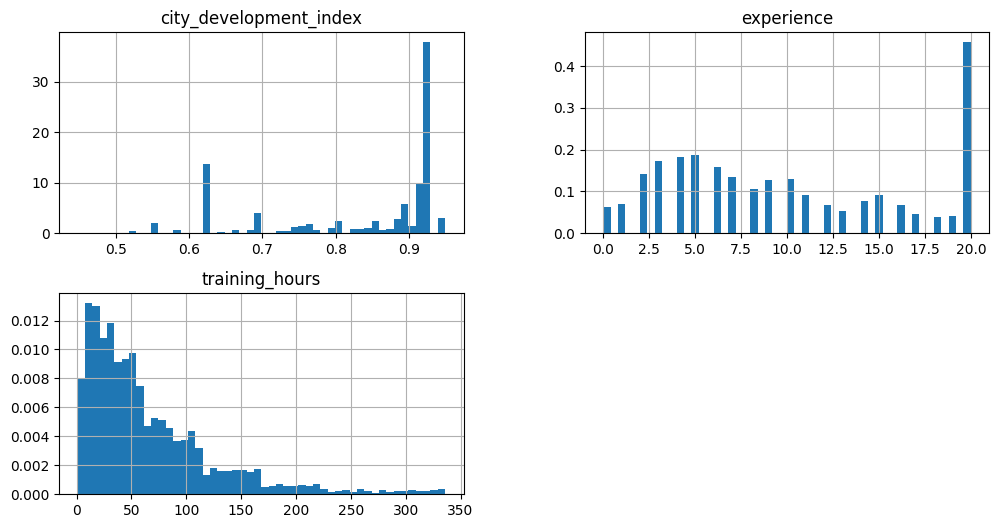

In [10]:
new_df.hist(bins=50,density=True,figsize=(12,6))
plt.show()

<Axes: >

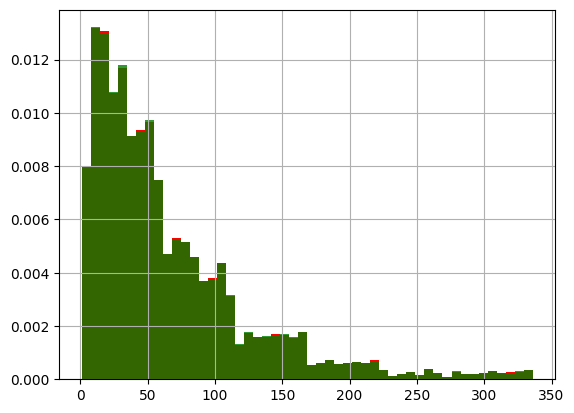

In [11]:
fig=plt.figure()
ax=fig.add_subplot(111)
df['training_hours'].hist(bins=50,ax=ax,density=True,color='red')
new_df['training_hours'].hist(bins=50,ax=ax,color='green',density=True,alpha=0.8)

<Axes: ylabel='Density'>

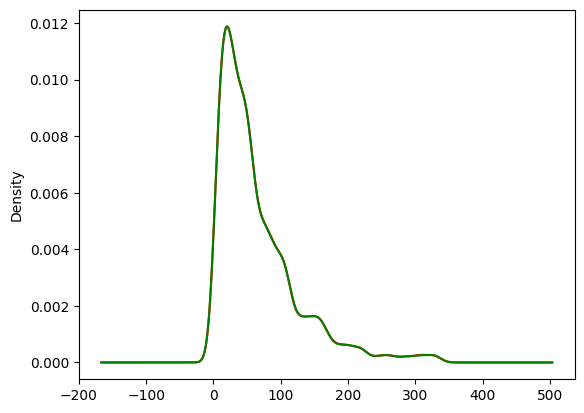

In [12]:
fig=plt.figure()
ax=fig.add_subplot(111)
df['training_hours'].plot.density(color='red')
new_df['training_hours'].plot.density(color='green')

<Axes: >

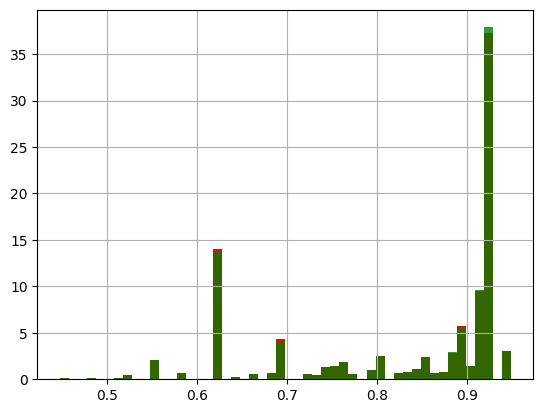

In [13]:
fig=plt.figure()
ax=fig.add_subplot(111)
df['city_development_index'].hist(bins=50,ax=ax,density=True,color='red')
new_df['city_development_index'].hist(bins=50,ax=ax,color='green',density=True,alpha=0.8)

<Axes: ylabel='Density'>

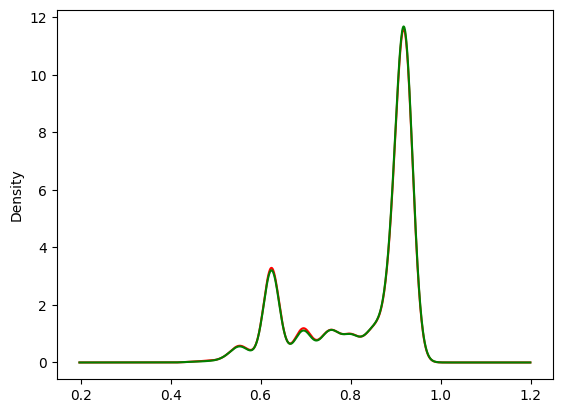

In [14]:
fig=plt.figure()
ax=fig.add_subplot(111)
df['city_development_index'].plot.density(color='red')
new_df['city_development_index'].plot.density(color='green')

<Axes: >

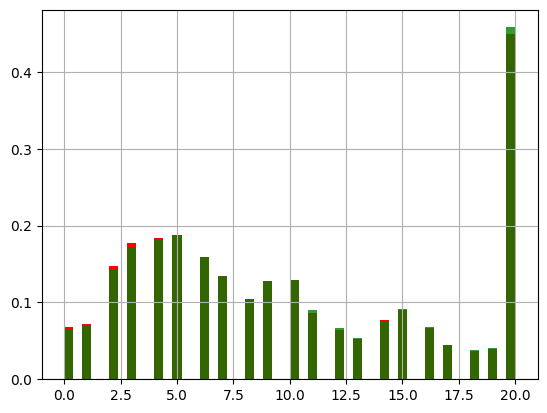

In [15]:
 fig=plt.figure()
ax=fig.add_subplot(111)
df['experience'].hist(bins=50,ax=ax,density=True,color='red')
new_df['experience'].hist(bins=50,ax=ax,color='green',density=True,alpha=0.8)

<Axes: ylabel='Density'>

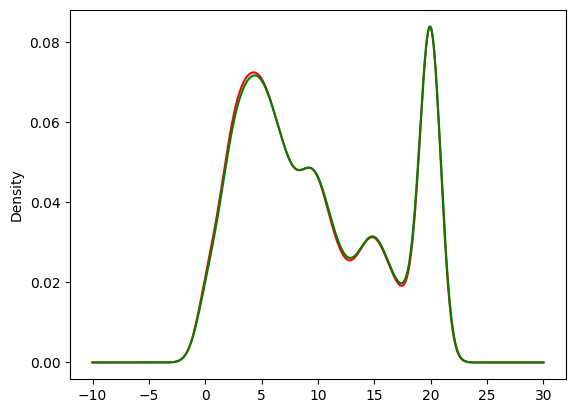

In [16]:
fig=plt.figure()
ax=fig.add_subplot(111)
df['experience'].plot.density(color='red')
new_df['experience'].plot.density(color='green')

In [17]:
 temp=pd.concat([df['enrolled_university'].value_counts()/len(df),
new_df['enrolled_university'].value_counts()/len(new_df)],axis=1)
temp.columns=['original','cca']
temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [18]:
temp=pd.concat([df['education_level'].value_counts()/len(df),
new_df['education_level'].value_counts()/len(new_df)],axis=1)
temp.columns=['original','cca']
temp

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
